Using device: cuda
Number of test events: 4475

Confusion matrix:
[[ 404  175]
 [ 126 3770]]


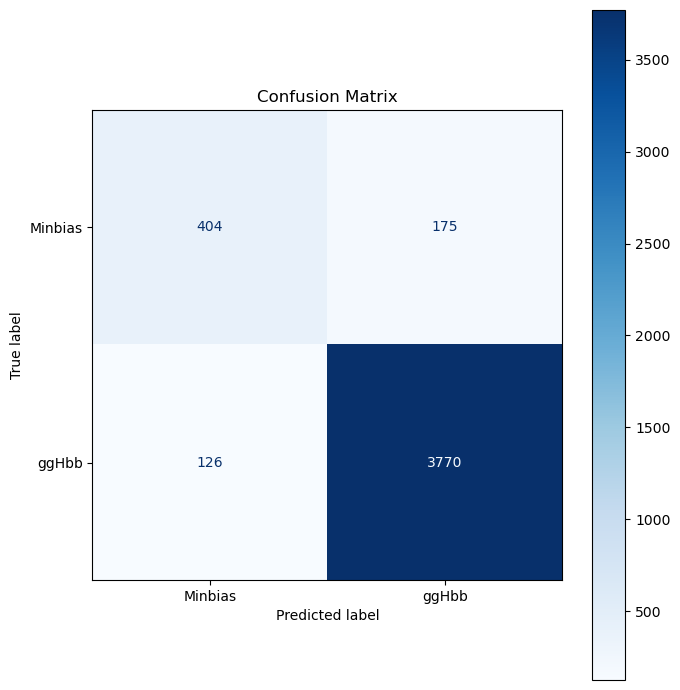


Normalized confusion matrix:
[[0.69775475 0.30224525]
 [0.03234086 0.96765914]]


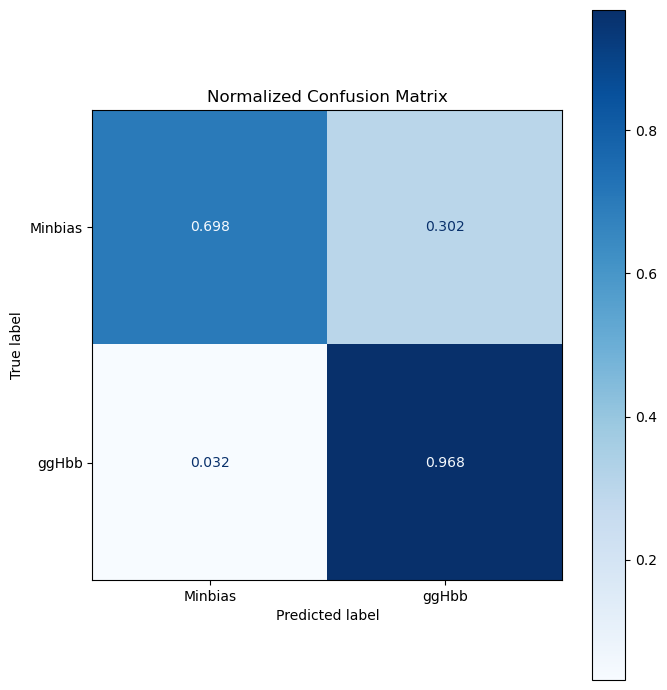


Done.


In [7]:
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import lightning as L

from classifier.dataset import TokenDataModule
from classifier.classifier_model import EncoderClassificationModule 


# Checkpoint
CHECKPOINT_PATH = "checkpoints_classifier/class/v1-epoch=05-val_loss=0.1571-class.ckpt"

# Processes
CLASS_NAMES = [
    "Minbias",
    "ggHbb",
]

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")


# ============================================================
# DATA MODULE
# ============================================================

data_module = TokenDataModule(
    tokens_path = "classifier/tokens/tokens.pt",
    masks_path = "classifier/tokens/masks.pt",
    labels_path = "classifier/tokens/labels.pt",
    cb_size = 1024,
    batch_size = 32,
    num_workers =0,
    test_size = 0.10,
    val_size = 0.20,
    seed = 56
)

data_module.setup(stage="test")

test_loader = data_module.test_dataloader()


# ============================================================
# LOAD MODEL FROM CHECKPOINT
# ============================================================

model = EncoderClassificationModule.load_from_checkpoint(
    CHECKPOINT_PATH
)

model = model.to(device)
model.eval()


# ============================================================
# INFERENCE
# ============================================================

all_labels = []
all_predictions = []
all_probabilities = []


with torch.no_grad():

    for batch_idx, batch in enumerate(test_loader):

        x = batch['tokens']
        mask = batch['mask']
        labels = batch['label']

        x = x.to(device)
        mask = mask.to(device)
        labels = labels.to(device)

        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits = model(x, mask)

        # ----------------------------------------------------
        # Binary classification
        # ----------------------------------------------------

        if logits.ndim == 1:
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

        elif logits.shape[-1] == 1:
            probabilities = torch.sigmoid(logits.squeeze(-1))
            predictions = (probabilities >= 0.5).long()

        # ----------------------------------------------------
        # Multi-class classification
        # ----------------------------------------------------

        else:
            probabilities = torch.softmax(logits, dim=-1)
            predictions = torch.argmax(probabilities, dim=-1)

        all_labels.append(labels.detach().cpu())
        all_predictions.append(predictions.detach().cpu())
        all_probabilities.append(probabilities.detach().cpu())


# ============================================================
# CONCATENATE
# ============================================================

y_true = torch.cat(all_labels).numpy()
y_pred = torch.cat(all_predictions).numpy()

print(f"Number of test events: {len(y_true)}")


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
)

print("\nConfusion matrix:")
print(cm)


# ============================================================
# RAW CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True,
)

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


# ============================================================
# NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    normalize="true",
)

print("\nNormalized confusion matrix:")
print(cm_normalized)


fig, ax = plt.subplots(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=CLASS_NAMES,
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".3f",
    colorbar=True,
)

ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

print("\nDone.")